<a href="https://colab.research.google.com/github/mokhivibes/ml_course_hometasks/blob/main/6_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!pip install opendatasets

In [27]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset/data")

Skipping, found downloaded files in "./car-price-prediction-dataset" (use force=True to force download)


In [28]:
import pandas as pd
df = pd.read_csv("/content/car-price-prediction-dataset/cardekho.csv")

In [29]:
#1-step=> check how many rows and columns in our data
df.shape

(8128, 12)

In [30]:
#2-step=> check what kind of data is stored in each column
df.head(20)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.30,1061.0,57.5,5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.10,796.0,37,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59,1364.0,67.1,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.00,1399.0,68.1,5.0


In [31]:
#3-step=> Read the column names and understand what each column represents
df.columns


Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power',
       'seats'],
      dtype='object')

In [32]:
#4-step=> Check the data types of each column (numbers, text, dates, etc.)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [33]:
#5-step => Count how many null/missing values exist in each column
df.isnull().sum().sort_values(ascending=False).head(20)


,0
seats,221
mileage(km/ltr/kg),221
engine,221
max_power,215
km_driven,0
selling_price,0
year,0
name,0
owner,0
transmission,0


In [34]:
missing = (df.isnull().sum() / len(df) * 100).round(2)
missing[missing >0].sort_values(ascending=False)
missing[missing >0].sort_values(ascending=False)


,0
mileage(km/ltr/kg),2.72
engine,2.72
seats,2.72
max_power,2.65


In [35]:
df.drop('seats', axis=1)
number_column_list = ['mileage(km/ltr/kg)', 'engine', 'max_power']
df[number_column_list].info()
import numpy as np

df['max_power'] = df['max_power'].replace(' ', np.nan).astype(float)
df[number_column_list] = df[number_column_list].fillna(df[number_column_list].mean())
df[number_column_list].isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mileage(km/ltr/kg)  7907 non-null   float64
 1   engine              7907 non-null   float64
 2   max_power           7913 non-null   object 
dtypes: float64(2), object(1)
memory usage: 190.6+ KB


,0
mileage(km/ltr/kg),0
engine,0
max_power,0


In [36]:
print(df.duplicated().sum())
df.drop_duplicates(keep='first', inplace=True)
df.shape

1202


(6926, 12)

In [37]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),0
engine,0


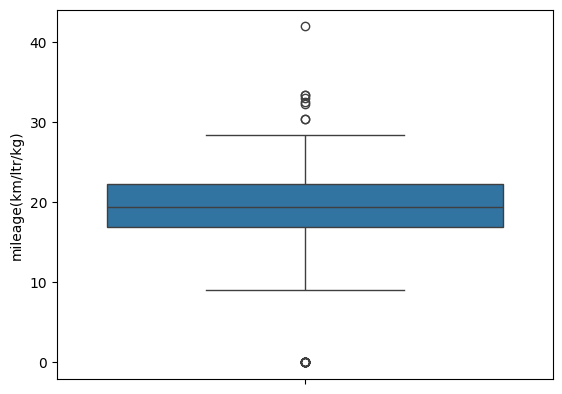

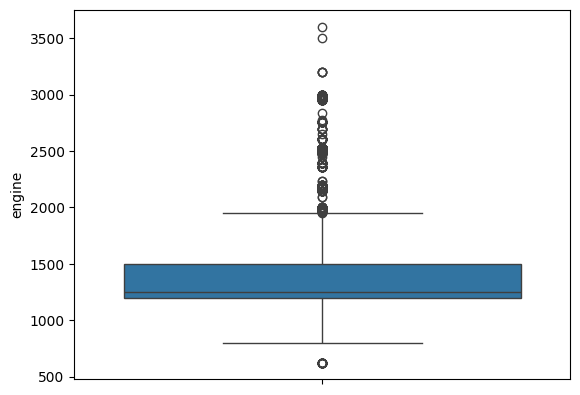

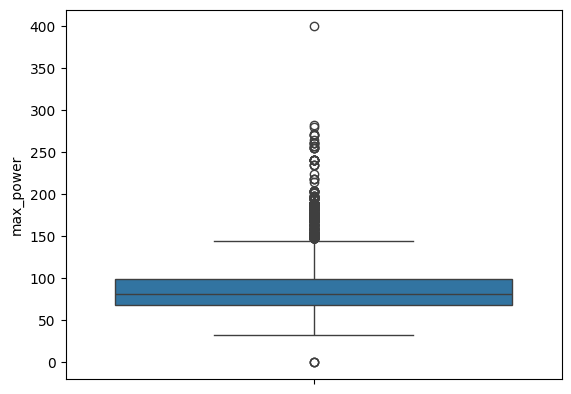

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in df[number_column_list]:
  sns.boxplot(data = df, y=column)
  plt.show()

In [39]:
df_clean = df.copy()

# for column in number_column_list:
#   Q1= df[column].quantile(0.25)
#   print(Q1)
#   Q3= df[column].quantile(0.75)
#   print(Q3)
#   IQR = Q3-Q1

  #Outlier filtr

  # mask = (df[column] <= (Q3+1.5*IQR)) & \
  #      (df[column] >= (Q1-1.5*IQR))
  # df_clean= df_clean[mask]

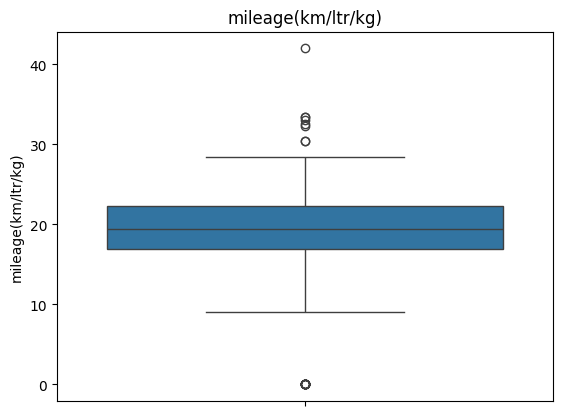

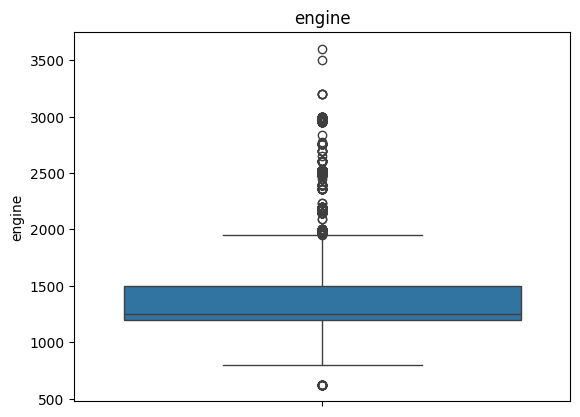

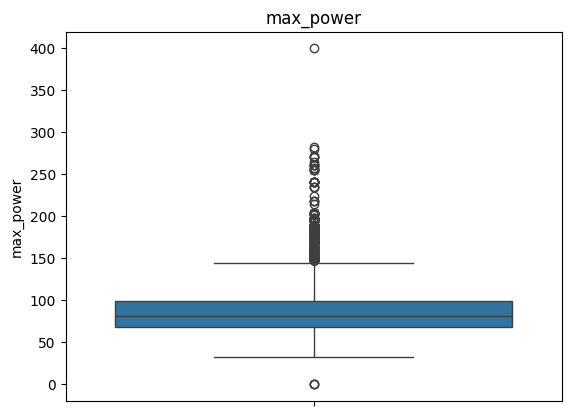

In [40]:
for column in number_column_list:
  sns.boxplot(data = df_clean, y=column)
  plt.title(column)
  plt.show()

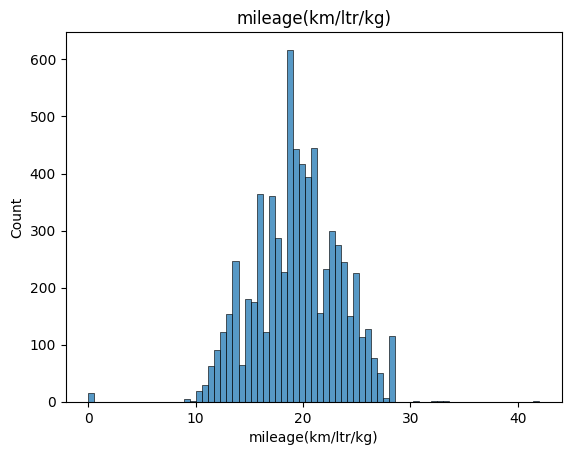

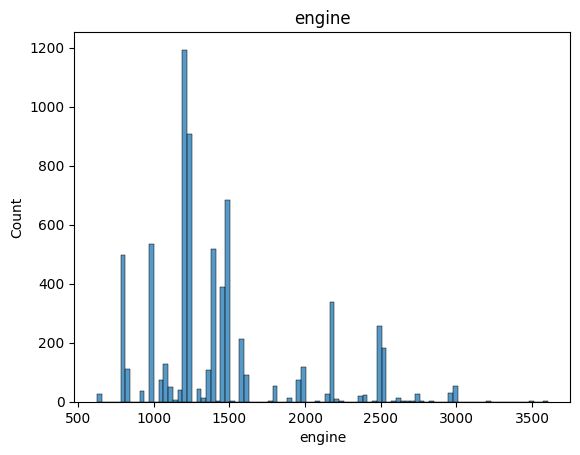

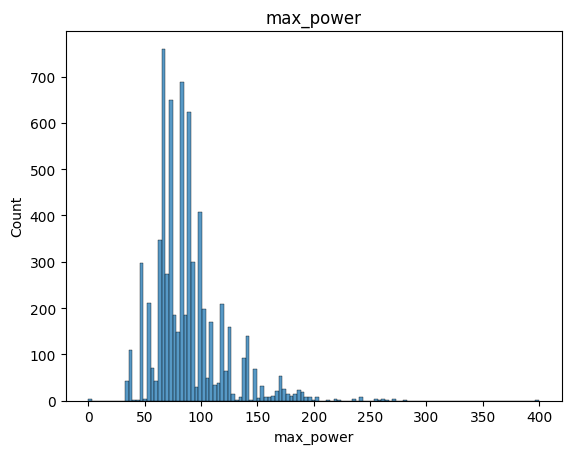

In [41]:
for column in number_column_list:
  sns.histplot(data = df_clean, x=column)
  plt.title(column)
  plt.show()

In [42]:
df_clean.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6718.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.463912,1431.724228,87.839675,5.434653
std,4.078286,5.197670e+05,5.835810e+04,3.987884,486.048519,31.302118,0.984230
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.950000,1197.000000,68.000000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.418783,1248.000000,81.860000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.320000,1498.000000,99.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


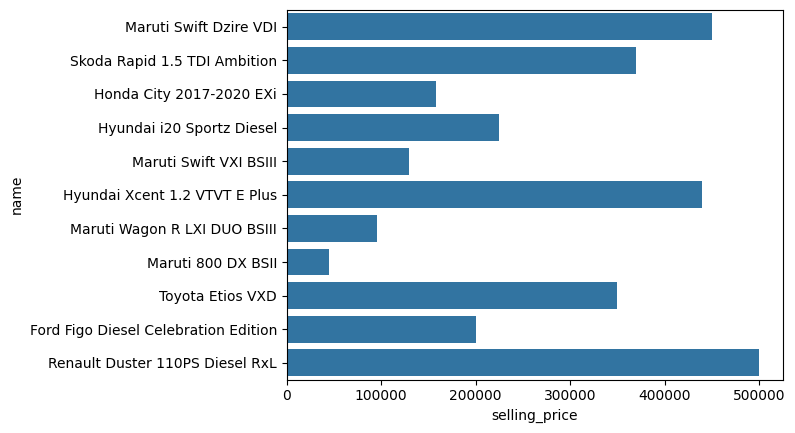

In [43]:
df_top10 = df_clean.head(11)
sns.barplot(data=df_top10, x='selling_price', y= 'name')
plt.show()

In [44]:
df_clean.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6718.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.463912,1431.724228,87.839675,5.434653
std,4.078286,5.197670e+05,5.835810e+04,3.987884,486.048519,31.302118,0.984230
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.950000,1197.000000,68.000000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.418783,1248.000000,81.860000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.320000,1498.000000,99.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


In [45]:
#Calculate skewness
skew_value = df['selling_price'].skew()

print("Skewness:", skew_value)
if skew_value > 1:
  print("Right skewed")
elif skew_value < 0:
  print("Left-skewed")
else:
  print("Normal")

Skewness: 5.572742292649192
Right skewed


12.864067426356216 0.7633396946697926 10.574048342346838 15.154086510365595


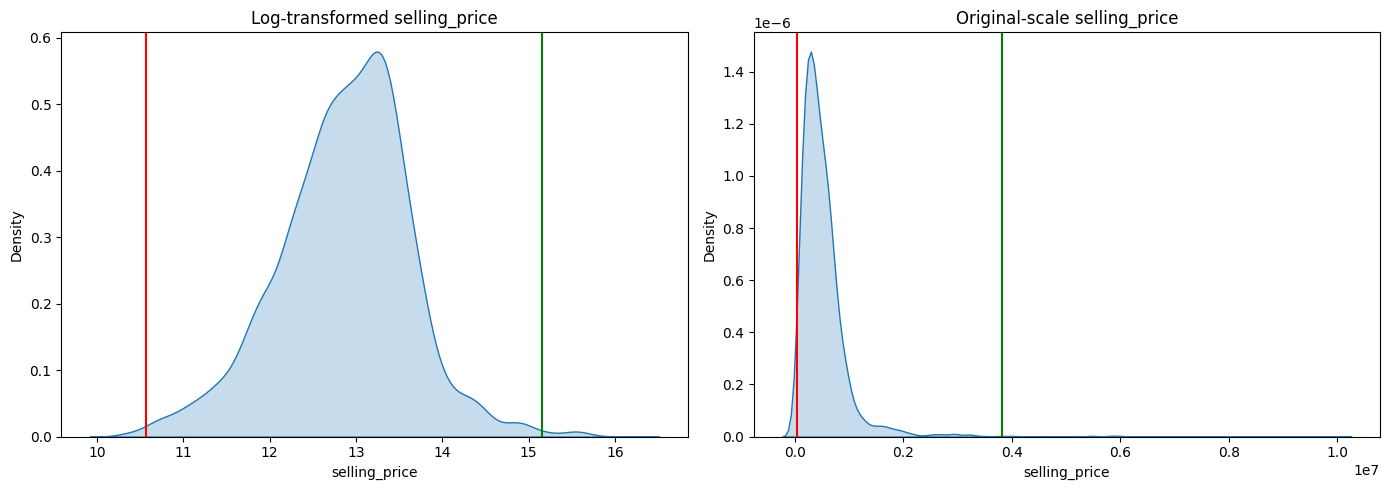

In [48]:
df_clean = df.copy()
df_clean['selling_price'] = np.log(df['selling_price'])
mu =df_clean['selling_price'].mean()
sigma = df_clean['selling_price'].std()
lower_bound = mu - 3*sigma
upper_bound = mu + 3*sigma
print(mu, sigma,  lower_bound, upper_bound)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: log-transformed data, with bounds in log-space
sns.kdeplot(data=df_clean, x='selling_price', fill=True, ax=axes[0])
axes[0].axvline(x=lower_bound, color='red')
axes[0].axvline(x=upper_bound, color='green')
axes[0].set_title('Log-transformed selling_price')

# Plot 2: original-scale data, with bounds converted back via exp()
sns.kdeplot(data=df, x='selling_price', fill=True, ax=axes[1])
axes[1].axvline(x=np.exp(lower_bound), color='red')
axes[1].axvline(x=np.exp(upper_bound), color='green')
axes[1].set_title('Original-scale selling_price')

plt.tight_layout()
plt.show()

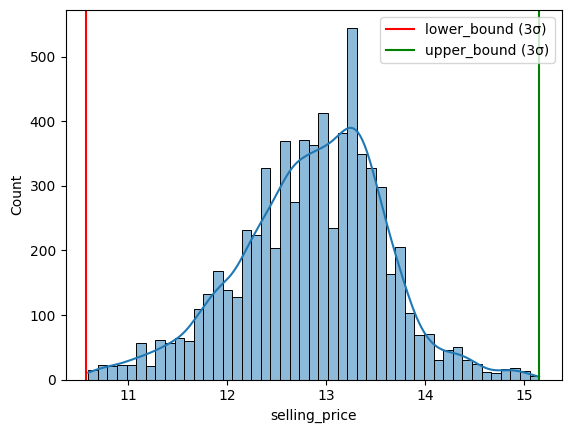

In [51]:
# Q1 = df_clean['selling_price'].quantile(0.25)
# Q3 = df_clean['selling_price'].quantile(0.75)
# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

df_clean  = df_clean[(df_clean['selling_price'] >= lower_bound) & (df_clean['selling_price'] <= upper_bound)]

# sns.boxplot(data=df_clean, x='selling_price')
# plt.show()


sns.histplot(data=df_clean, x='selling_price', kde=True)
plt.axvline(x=lower_bound, color='red', label='lower_bound (3σ)')
plt.axvline(x=upper_bound, color='green', label='upper_bound (3σ)')
plt.legend()
plt.show()
